# Market Basket Analysis

---

**Author:** Raditya Zaki Athaya   
**Notebook:** `03_market_basket_analysis.ipynb`

---

## Project Overview

Market Basket Analysis (MBA) bertujuan menemukan pola asosiasi antar produk yang sering dibeli bersamaan dalam satu transaksi. Dengan menggunakan algoritma **Apriori**, kita dapat mengidentifikasi *association rules* seperti:

> *"Pelanggan yang membeli produk A cenderung juga membeli produk B."*

Output analisis ini digunakan untuk dua tujuan bisnis utama:
1. **Cross-selling:** Merekomendasikan produk pelengkap secara otomatis di halaman checkout.
2. **Bundle Promotion:** Merancang paket produk dengan harga khusus berdasarkan kombinasi yang terbukti sering dibeli bersamaan.

## 1. Import Library & Load Data

Selain library standar, notebook ini menggunakan `mlxtend` — library machine learning yang menyediakan implementasi algoritma Apriori dan fungsi `association_rules` siap pakai.

Pastikan library sudah terinstall:
```bash
pip install mlxtend
```

In [2]:
# ── Standard Libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# ── mlxtend: Apriori & Association Rules ─────────────────────────────────────
from mlxtend.frequent_patterns import apriori, association_rules

# ── Global Config ────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# ── Load Cleaned Dataset ─────────────────────────────────────────────────────
CLEANED_PATH = '../data/processed/ecommerce_cleaned.csv'

df = pd.read_csv(CLEANED_PATH, dtype={'CustomerID': str, 'InvoiceNo': str})
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Unique countries: {df['Country'].nunique()}")
print(f"Unique invoices : {df['InvoiceNo'].nunique():,}")
df.head()

Dataset loaded: 392,692 rows x 13 columns
Unique countries: 37
Unique invoices : 18,532


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,Year,Month,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.5500,17850,United Kingdom,15.3000,2010,12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.3900,17850,United Kingdom,20.3400,2010,12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.7500,17850,United Kingdom,22.0000,2010,12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.3900,17850,United Kingdom,20.3400,2010,12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.3900,17850,United Kingdom,20.3400,2010,12,Wednesday,8


## 2. Data Preparation (Basket Matrix)

Untuk analisis ini, kita fokus pada transaksi dari **United Kingdom** saja, dengan dua alasan:

1. **Efisiensi memori** — UK mendominasi ~90% transaksi. Memasukkan semua negara akan menghasilkan matriks yang sangat sparse dan lambat diproses.
2. **Spesifisitas pasar** — Perilaku pembelian antar negara bisa berbeda. Fokus pada satu pasar menghasilkan rules yang lebih relevan dan dapat ditindaklanjuti.

Langkah transformasi:
- `groupby` invoice dan produk → agregasi total quantity
- `unstack` → pivot menjadi *basket matrix* (baris = invoice, kolom = produk)
- Encode: semua nilai ≥ 1 → `1` (dibeli), nilai ≤ 0 → `0` (tidak dibeli)

In [3]:
# ── Filter: Hanya Transaksi United Kingdom ────────────────────────────────────
df_uk = df[df['Country'] == 'United Kingdom'].copy()

print(f"Transaksi UK : {len(df_uk):,} rows")
print(f"Unique invoices UK: {df_uk['InvoiceNo'].nunique():,}")

# ── Buat Basket Matrix ────────────────────────────────────────────────────────
# Baris = InvoiceNo, Kolom = nama produk (Description), Nilai = total Quantity
basket = (
    df_uk
    .groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack(fill_value=0)
)

print(f"\nBasket matrix shape: {basket.shape}")
print(f"  → {basket.shape[0]:,} invoices x {basket.shape[1]:,} unique products")

# ── Encode: Ubah Quantity menjadi Binary (0/1) ────────────────────────────────
def encode_units(x):
    # Quantity <= 0 → 0 (tidak dibeli / retur)
    # Quantity >= 1 → 1 (dibeli)
    return 0 if x <= 0 else 1

basket_encoded = basket.map(encode_units)

# Verifikasi: pastikan hanya ada nilai 0 dan 1
assert basket_encoded.isin([0, 1]).all().all(), "Masih ada nilai selain 0 dan 1!"

print(f"\nEncoding selesai. Sparsity matrix:")
total_cells  = basket_encoded.shape[0] * basket_encoded.shape[1]
filled_cells = basket_encoded.sum().sum()
print(f"  Cells berisi 1 : {filled_cells:,} ({filled_cells/total_cells*100:.2f}%)")
print(f"  Cells berisi 0 : {total_cells - filled_cells:,} ({(total_cells-filled_cells)/total_cells*100:.2f}%)")

Transaksi UK : 349,203 rows
Unique invoices UK: 16,646

Basket matrix shape: (16646, 3844)
  → 16,646 invoices x 3,844 unique products

Encoding selesai. Sparsity matrix:
  Cells berisi 1 : 344,342 (0.54%)
  Cells berisi 0 : 63,642,882 (99.46%)


## 3. Frequent Itemsets (Apriori)

Algoritma **Apriori** bekerja dengan mencari kombinasi produk yang muncul bersama dalam transaksi melebihi ambang batas **minimum support**.

**Support** didefinisikan sebagai:

$$\text{support}(A) = \frac{\text{jumlah transaksi yang mengandung } A}{\text{total seluruh transaksi}}$$

Kita menggunakan `min_support = 0.02` (2%), artinya sebuah kombinasi produk harus muncul di minimal 2% dari seluruh invoice UK. Nilai ini dipilih karena:
- Terlalu tinggi (misal 10%) → terlalu sedikit itemsets yang ditemukan
- Terlalu rendah (misal 0.5%) → terlalu banyak kombinasi, komputasi berat

Parameter `use_colnames=True` memastikan output menggunakan nama produk, bukan indeks kolom.

In [4]:
# ── Jalankan Algoritma Apriori ────────────────────────────────────────────────
frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.02,    # minimal muncul di 2% transaksi
    use_colnames=True    # gunakan nama produk (bukan indeks)
)

# Tambahkan kolom jumlah item dalam setiap itemset
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets ditemukan: {len(frequent_itemsets):,}")
print(f"\nDistribusi berdasarkan jumlah item:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

# ── Top 10 Frequent Itemsets berdasarkan Support ──────────────────────────────
print("\nTop 10 Frequent Itemsets (by Support):")
frequent_itemsets.sort_values('support', ascending=False).head(10)

Total frequent itemsets ditemukan: 235

Distribusi berdasarkan jumlah item:
length
1    199
2     35
3      1

Top 10 Frequent Itemsets (by Support):


,support,itemsets,length
184,0.1132,frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),1
79,0.0869,frozenset({JUMBO BAG RED RETROSPOT}),1
149,0.0847,frozenset({REGENCY CAKESTAND 3 TIER}),1
11,0.0781,frozenset({ASSORTED COLOUR BIRD ORNAMENT}),1
123,0.0775,frozenset({PARTY BUNTING}),1
101,0.0673,frozenset({LUNCH BAG RED RETROSPOT}),1
159,0.0605,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN }),1
94,0.0598,frozenset({LUNCH BAG BLACK SKULL.}),1
119,0.0568,frozenset({PAPER CHAIN KIT 50'S CHRISTMAS }),1
108,0.0563,frozenset({NATURAL SLATE HEART CHALKBOARD }),1


## 4. Association Rules

Dari frequent itemsets, kita generate **association rules** — aturan berbentuk `{A} → {B}`. Dua metrik utama yang digunakan:

| Metrik | Formula | Interpretasi |
|--------|---------|--------------|
| **Confidence** | P(B\|A) | Probabilitas B dibeli jika A sudah ada di keranjang. Confidence 0.7 = 70% pembeli A juga membeli B. |
| **Lift** | Confidence / Support(B) | Seberapa jauh lebih sering A dan B dibeli bersama dibanding jika keduanya independen. Lift > 1 = asosiasi positif (bukan kebetulan). |

Kita filter dengan `lift >= 1.0` — hanya rules yang menunjukkan asosiasi nyata yang dipertahankan.

In [5]:
# ── Generate Association Rules ────────────────────────────────────────────────
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0,    # hanya rules dengan lift > 1 (asosiasi positif)
    num_itemsets=len(frequent_itemsets)
)

# ── Sorting: Lift descending, lalu Confidence descending ─────────────────────
rules = rules.sort_values(
    ['lift', 'confidence'],
    ascending=[False, False]
).reset_index(drop=True)

print(f"Total association rules ditemukan: {len(rules):,}")
print(f"\nRange metrik:")
print(f"  Support    : {rules['support'].min():.4f} – {rules['support'].max():.4f}")
print(f"  Confidence : {rules['confidence'].min():.4f} – {rules['confidence'].max():.4f}")
print(f"  Lift       : {rules['lift'].min():.4f} – {rules['lift'].max():.4f}")

# ── Tampilkan 10 Rules Teratas ────────────────────────────────────────────────
print("\nTop 10 Association Rules (sorted by Lift):")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Total association rules ditemukan: 76

Range metrik:
  Support    : 0.0200 – 0.0304
  Confidence : 0.2272 – 0.8903
  Lift       : 3.8723 – 24.2167

Top 10 Association Rules (sorted by Lift):


,antecedents,consequents,support,confidence,lift
0,"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.0205,0.8903,24.2167
1,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",0.0205,0.5572,24.2167
2,"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.0205,0.7164,24.1886
3,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",0.0205,0.6917,24.1886
4,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.0243,0.6601,22.2891
5,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.0243,0.8195,22.2891
6,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.0205,0.5029,20.7230
7,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.0205,0.8441,20.7230
8,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.0286,0.7778,19.0957
9,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.0286,0.7021,19.0957


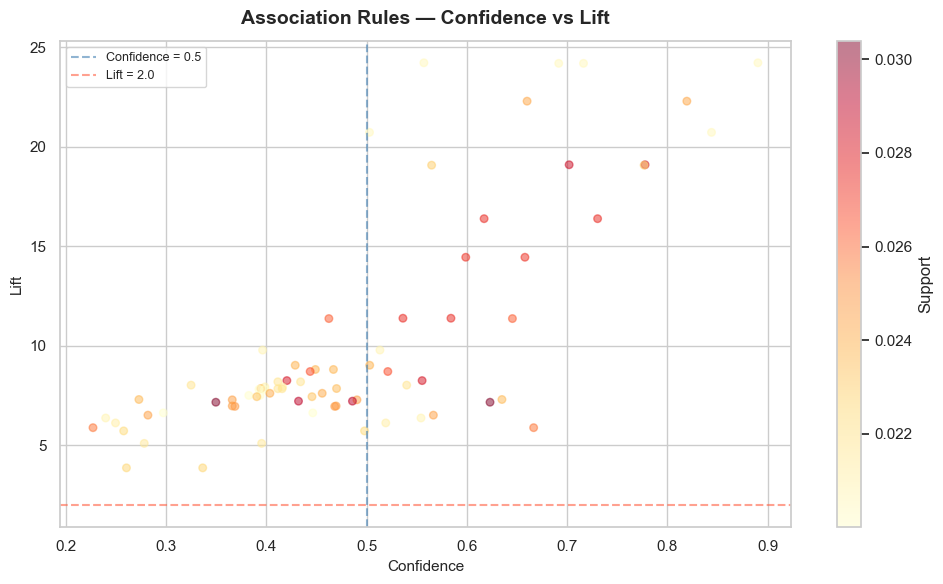

In [6]:
# ── Visualisasi: Scatter Plot Confidence vs Lift ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    rules['confidence'],
    rules['lift'],
    alpha=0.5,
    c=rules['support'],     # warna berdasarkan nilai support
    cmap='YlOrRd',
    s=30
)

plt.colorbar(scatter, ax=ax, label='Support')
ax.set_title('Association Rules — Confidence vs Lift', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Confidence', fontsize=11)
ax.set_ylabel('Lift', fontsize=11)
ax.axvline(x=0.5, color='steelblue', linestyle='--', alpha=0.6, label='Confidence = 0.5')
ax.axhline(y=2.0, color='tomato',    linestyle='--', alpha=0.6, label='Lift = 2.0')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

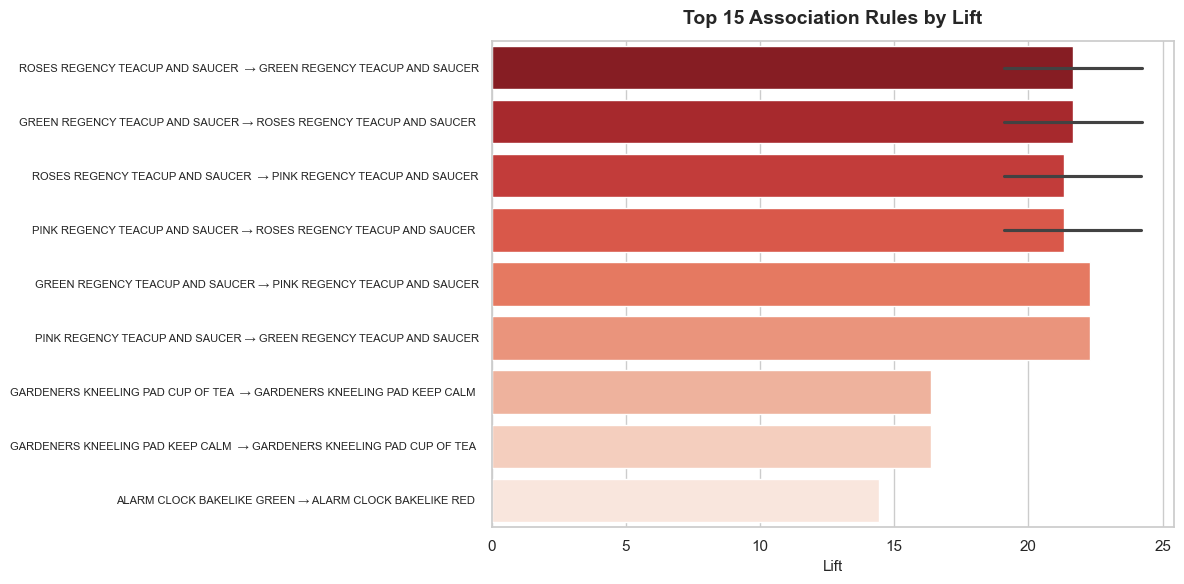

In [7]:
# ── Visualisasi: Top 15 Rules by Lift (Bar Chart) ────────────────────────────
top_rules = rules.head(15).copy()

# Buat label singkat untuk setiap rule
top_rules['rule_label'] = (
    top_rules['antecedents'].apply(lambda x: ', '.join(list(x)[:1])) +
    ' → ' +
    top_rules['consequents'].apply(lambda x: ', '.join(list(x)[:1]))
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_rules, x='lift', y='rule_label', palette='Reds_r', ax=ax)

ax.set_title('Top 15 Association Rules by Lift', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Lift', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

In [8]:
# ── Export Association Rules ─────────────────────────────────────────────
OUTPUT_RULES_PATH = '../data/processed/association_rules.csv'

# Mengubah format antecedents & consequents dari 'frozenset' menjadi string biasa 
# agar mudah dibaca oleh Tableau
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Simpan ke CSV
rules.to_csv(OUTPUT_RULES_PATH, index=False)

print(f"Association rules saved to: {OUTPUT_RULES_PATH}")

Association rules saved to: ../data/processed/association_rules.csv


## 5. Business Recommendations

Dari 76 association rules yang ditemukan (berbasis 16,646 transaksi UK), seluruh top rules dengan lift tertinggi (19x–24x) didominasi oleh satu cluster produk: **Regency Teacup & Saucer Series** (Green, Pink, Roses). Ini bukan kebetulan — cluster ini adalah sinyal bisnis yang sangat kuat.

---

**1. Cross-Selling Otomatis di Halaman Checkout**

Rule terkuat: `ROSES + PINK REGENCY TEACUP AND SAUCER → GREEN REGENCY TEACUP AND SAUCER`
Lift: **24.22x** | Confidence: **89%**

89% pelanggan yang membeli dua varian pertama terbukti juga membeli varian ketiga. Dengan lift 24x di atas baseline independen, asosiasi ini jauh dari kebetulan. Rekomendasikan GREEN REGENCY TEACUP AND SAUCER secara otomatis di halaman checkout setiap kali salah satu varian lain masuk keranjang.

---

**2. Bundle Promotion — Regency Teacup Complete Set**

Rule: `GREEN REGENCY TEACUP AND SAUCER → ROSES + PINK REGENCY TEACUP AND SAUCER`
Lift: **24.22x** | Confidence: **56%**

Lebih dari separuh pembeli GREEN varian langsung melengkapi dengan dua varian lainnya. Buat paket **"Regency Teacup Complete Set"** (ketiga varian sekaligus) dengan diskon 10–15%. Bundle ini tidak memaksa karena polanya sudah organik terjadi di data — diskon hanya mempercepat keputusan pelanggan yang memang cenderung membeli ketiganya.

---

**3. Cart Abandonment Recovery via Email / Push Notification**

Rule: `GREEN + ROSES REGENCY TEACUP AND SAUCER → PINK REGENCY TEACUP AND SAUCER`
Lift: **24.19x** | Confidence: **72%**

Jika pelanggan meninggalkan keranjang yang berisi dua varian GREEN dan ROSES tanpa checkout, kirim reminder yang menyertakan PINK REGENCY TEACUP AND SAUCER sebagai produk yang "sering dilengkapi pelanggan lain." Confidence 72% membuat rekomendasi ini sangat relevan — dua tujuan sekaligus: recovery transaksi gagal dan peluang upsell dalam satu touchpoint.